**Nikhil Sunder**  
ICSRI Research Fellow, University of Miami | Open-Source Developer  
Herbert Business School, University of Miami  
B.S.B.A. Quantitative Economics & Finance; Minor in Mathematics  

**Correspondence:** nss106@miami.edu  
**Research profiles:** [GitHub](https://github.com/nikhilxsunder) · [ORCID](https://orcid.org/0009-0007-3323-1760) · [LinkedIn](https://www.linkedin.com/in/nikhil-sunder/) · [Zenodo](https://zenodo.org/search?q=metadata.creators.person_or_org.name:%22Sunder,+Nikhil%22)  
**Software:** [PyPI](https://pypi.org/user/nikhil.sunder/) · [Anaconda](https://anaconda.org/nikhil.sunder/)

# 11. Reinforcement learning: robustness and comparison

Every trained policy of notebooks `08` to `10`, side by side: closed-loop variances in the
Rudebusch-Svensson (1999) model, effective Taylor coefficients, and simulated paths and losses in the
economies the policies were trained in.

**Inputs:** `artifacts/rl/ddpg/`, `artifacts/rl/sac/`, `artifacts/rl/qlearning/` and the artifacts of
notebooks `00` to `07`. This notebook trains nothing.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import autofed as af
from autofed import plots, rl
from autofed.style import COLORS

nb = af.NotebookSession(
    "11_rl_robustness_comparison",
    number=11,
    title="Reinforcement learning: robustness and comparison",
)

lab = rl.PolicyLab.load(
    nb.workspace.artifacts
)  # economies of notebooks 01-06, settings of notebook 07
cfg = lab.config
OBS_SPECS = ["x1", "x2"]
LOSS_COLUMNS = {
    "dev2 pi": r"$\Delta^2(\pi^*, \pi_t)$",
    "dev2 y": r"$\Delta^2(y^*, y_t)$",
    "dev2 di": r"$\Delta^2(\Delta i_t)$",
}
PATH_NOTE = (
    "Simulated from the first two estimation-window quarters under freshly drawn shocks; every"
    " policy faces the same shocks within an economy. Not a historical counterfactual."
)


def slug(name: str) -> str:
    return name.lower().replace("-", "_").replace(" ", "_")


print(
    "Economies:",
    ", ".join(lab.env_names),
    "| frames per run:",
    cfg.total_timesteps,
    "| seed:",
    cfg.seed,
)

ALGORITHMS = {"DDPG": "ddpg", "SAC": "sac", "Q-learning": "qlearning"}
cells = [
    cell for folder in ALGORITHMS.values() for cell in rl.load_cells(nb.artifacts("rl", folder))
]
print(
    "Loaded", {algo: sum(c.algo == algo for c in cells) for algo in ALGORITHMS}, "trained cells"
)

Economies: SVAR, TVP-SVAR-SV, NARX, NSSM | frames per run: 12500 | seed: 2026
Loaded {'DDPG': 16, 'SAC': 8, 'Q-learning': 4} trained cells


## DSGE robustness exercise (Rudebusch-Svensson 1999)

### Methodology

Hinterlang & Tänzer (2021, Section 3.4 and Table 7) evaluate their optimised reaction functions
on 11 DSGE models from the Macroeconomic Model Database (Wieland et al., 2012, 2016) and report
the unconditional variances of inflation, the output gap, and the change in the policy rate
*relative to* the Taylor (1993) rule under each model. The exercise is a robustness check: a
policy rule that is optimised for one estimated economy (the SVAR or the ANN) is not guaranteed
to perform well in other plausible structural representations, and the DSGE comparison establishes
that the RL-optimised rules remain reasonably robust across models.

A full replication requires solving forward-looking rational-expectations DSGE models with Sims's
(2002) `gensys` or an equivalent (the Macroeconomic Model Database is built on `dynare`). Our
notebook does not embed `dynare`, so a strict replication of all 11 H&T models is out of scope.
We instead implement the *backward-looking* subset of the H&T robustness exercise, which reduces to a
closed-form solve. The canonical backward-looking benchmark in the monetary-policy literature is
Rudebusch & Svensson (1999, henceforth RS99), which H&T cite explicitly. We compute the unconditional
variance of each variable under the closed-loop dynamics induced by each candidate policy rule and
report the variances relative to the Taylor (1993) baseline.

This notebook evaluates every trained policy of notebooks `08` to `10`.

### Rudebusch-Svensson (1999) closed-form solver

The RS99 model is

$$\begin{aligned}
y_t &= 1.1597 y_{t-1} - 0.2588 y_{t-2} - 0.0908 (i_{t-1} - \bar{\pi}_{t-1}) + \varepsilon_t^y, \\
\pi_t &= 0.701 \pi_{t-1} + 0.3 \pi_{t-2} - 0.1 \pi_{t-3} + 0.1 \pi_{t-4} + 0.1397 y_{t-1} + \varepsilon_t^\pi, \\
\bar{\pi}_{t-1} &= \tfrac{1}{4}(\pi_{t-1} + \pi_{t-2} + \pi_{t-3} + \pi_{t-4}),
\end{aligned}$$

with shock standard deviations $\sigma_y = 0.819$ and $\sigma_\pi = 1.013$. We adopt the H&T
policy rule format with one lag, in deviations from steady state,

$$i_t = \beta_\pi^0 \pi_t + \beta_\pi^1 \pi_{t-1} + \beta_y^0 y_t + \beta_y^1 y_{t-1},$$

stack the system in the state $z_t = (y_t, y_{t-1}, \pi_t, \pi_{t-1}, \pi_{t-2}, \pi_{t-3})$,
substitute the policy rule, and solve for the closed-loop $F(K)$ such that
$z_{t+1} = F(K) z_t + \eta_{t+1}$. The unconditional state-covariance matrix is the unique
stable solution of the discrete-time Lyapunov equation $V = FVF^\top + \Sigma$. With six states the
vectorised form $\mathrm{vec}(V) = (I - F \otimes F)^{-1}\mathrm{vec}(\Sigma)$ is a 36-equation linear
system, solved directly with `torch.linalg.solve`.

### Policy coefficients

Each trained policy enters through its `linearise_policy` coefficients (the OLS approximation of the
clipped policy). The slopes are the same in level and deviation form, so they enter the log-linearised
rule unchanged; the lag coefficients are zero because the grid sets lagged inputs equal to current ones.
Values below 1 mean the rule lowers that variance relative to the Taylor (1993) rule; `inf` marks an
unstable closed loop.

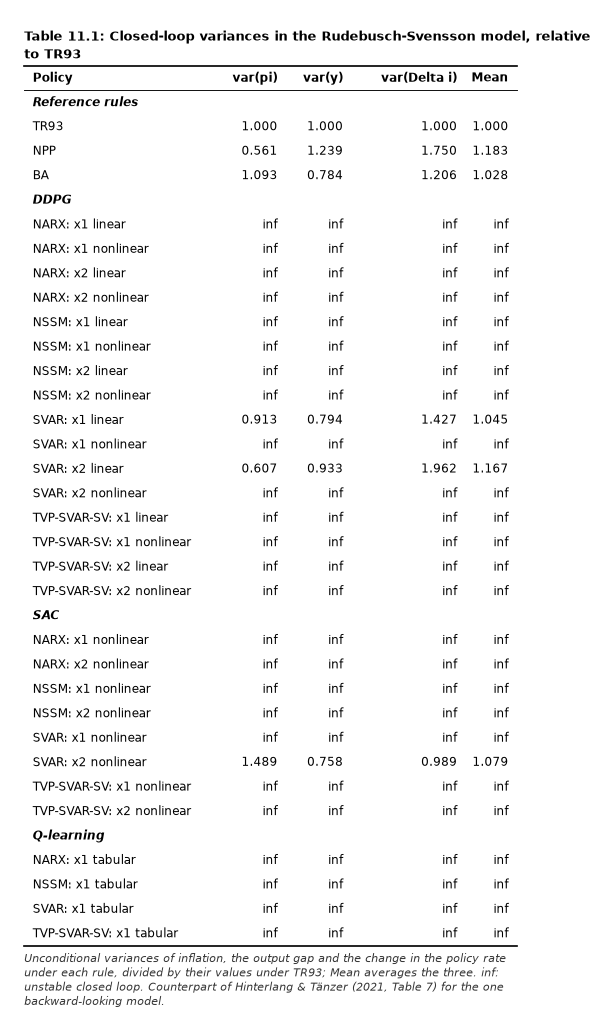

In [2]:
coefficients = {
    name: {"beta_pi_0": policy.rule.beta_pi, "beta_y_0": policy.rule.beta_y}
    for name, policy in lab.reference_rules().items()
}
groups = {name: "Reference rules" for name in coefficients}
for cell in cells:
    linear = rl.linearise_policy(cell)
    name = f"{cell.algo} | {cell.env_name}: {cell.obs_spec} {cell.variant}"
    coefficients[name] = {"beta_pi_0": linear["beta_pi"], "beta_y_0": linear["beta_y"]}
    groups[name] = cell.algo

rs99 = rl.rs99_table(coefficients)
rs99.index = pd.MultiIndex.from_tuples(
    [(groups[name], name.split(" | ")[-1]) for name in rs99.index],
    names=["Algorithm", "Policy"],
)
nb.table(
    rs99,
    "rs99_variance_ratios",
    "Closed-loop variances in the Rudebusch-Svensson model, relative to TR93",
    fontsize=8.0,
    note=(
        "Unconditional variances of inflation, the output gap and the change in the policy rate"
        " under each rule, divided by their values under TR93; Mean averages the three. inf:"
        " unstable closed loop. Counterpart of Hinterlang & Tänzer (2021, Table 7) for the one"
        " backward-looking model."
    ),
)

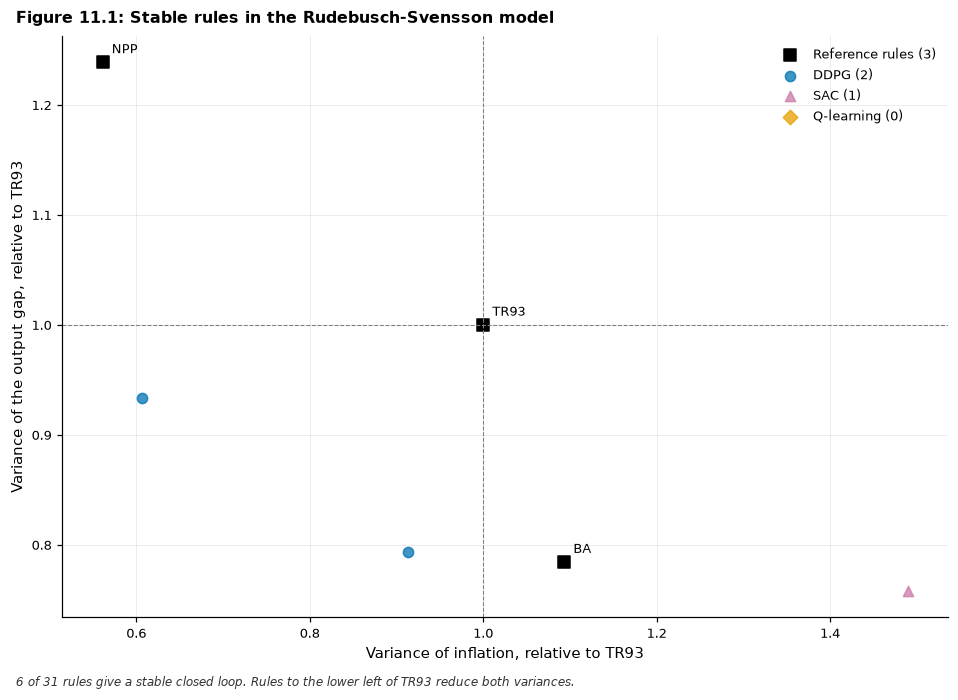

In [3]:
stable = rs99[np.isfinite(rs99["Mean"])]
fig, ax = plt.subplots(figsize=(8.6, 6.0))
markers = {
    "Reference rules": ("s", COLORS["black"]),
    "DDPG": ("o", COLORS["blue"]),
    "SAC": ("^", COLORS["purple"]),
    "Q-learning": ("D", COLORS["orange"]),
}
for group, (marker, color) in markers.items():
    part = stable[stable.index.get_level_values("Algorithm") == group]
    ax.scatter(
        part["var(pi)"],
        part["var(y)"],
        marker=marker,
        color=color,
        s=70 if group == "Reference rules" else 45,
        alpha=1.0 if group == "Reference rules" else 0.75,
        label=f"{group} ({len(part)})",
    )
for (group, name), row in stable.iterrows():
    if group == "Reference rules":
        ax.annotate(
            name,
            (row["var(pi)"], row["var(y)"]),
            xytext=(6, 6),
            textcoords="offset points",
            fontsize=8.5,
        )
ax.axhline(1.0, color=COLORS["grey"], lw=0.7, ls="--")
ax.axvline(1.0, color=COLORS["grey"], lw=0.7, ls="--")
ax.set_xlabel("Variance of inflation, relative to TR93")
ax.set_ylabel("Variance of the output gap, relative to TR93")
ax.legend(loc="best")
nb.figure(
    fig,
    "rs99_variance_scatter",
    "Stable rules in the Rudebusch-Svensson model",
    note=(
        f"{len(stable)} of {len(rs99)} rules give a stable closed loop. Rules to the lower left"
        " of TR93 reduce both variances."
    ),
)

## Effective Taylor coefficients, all algorithms

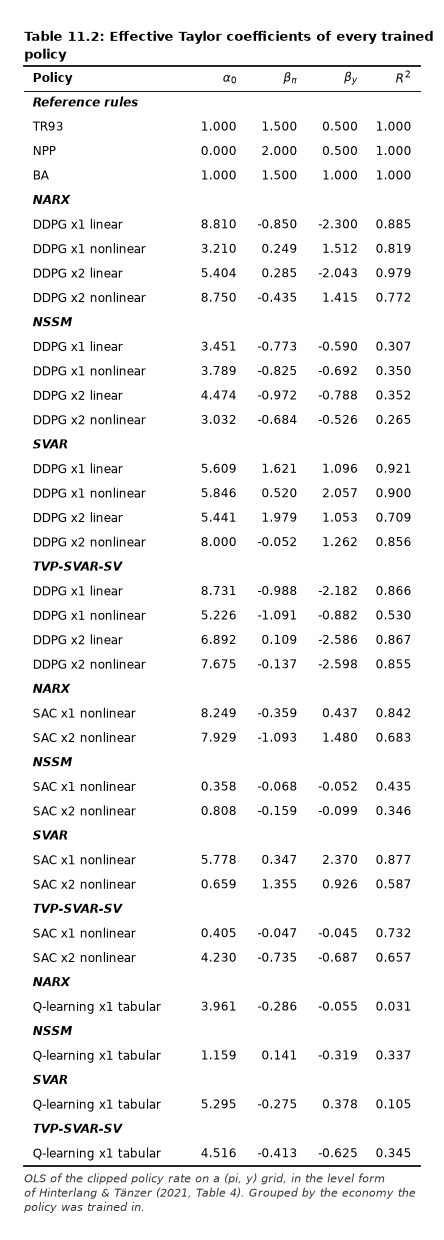

In [4]:
nb.table(
    rl.coefficient_table(cells),
    "taylor_coefficients",
    "Effective Taylor coefficients of every trained policy",
    fontsize=8.0,
    note=(
        "OLS of the clipped policy rate on a (pi, y) grid, in the level form of Hinterlang &"
        " Tänzer (2021, Table 4). Grouped by the economy the policy was trained in."
    ),
)

## Simulated paths and losses, all algorithms

Each policy is simulated in the economy it was trained in. The figures show the reference rules and, for
each algorithm, the policy with the lowest loss in that economy; the table lists every policy.

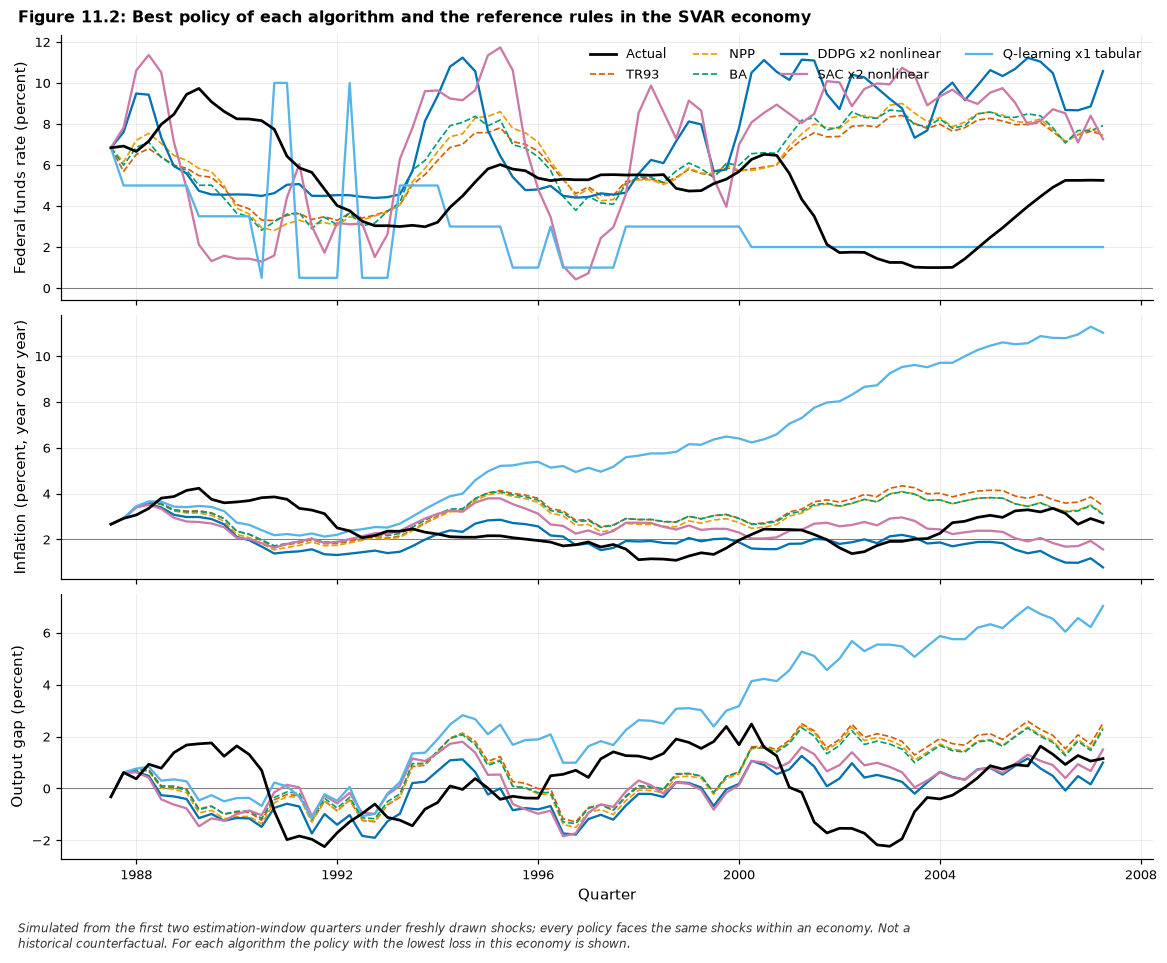

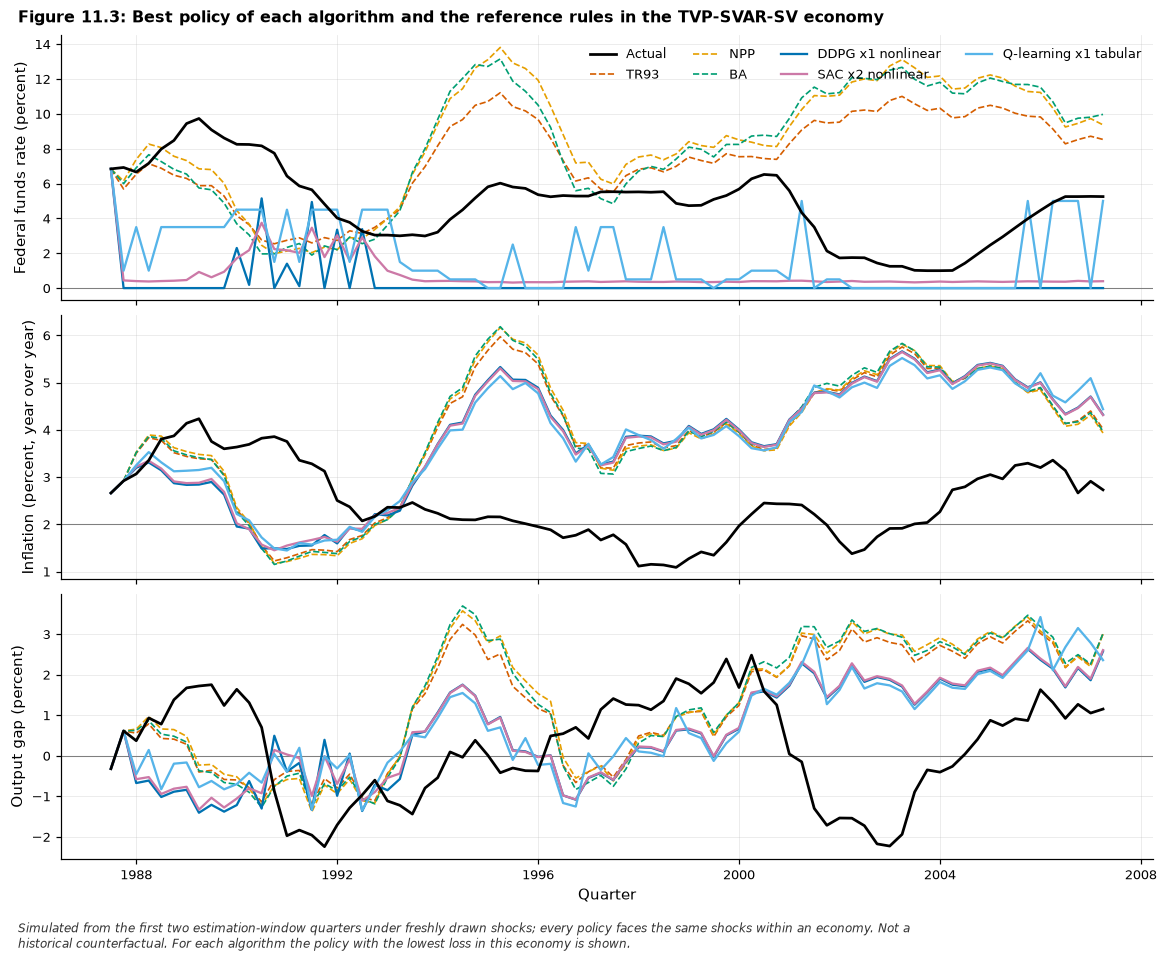

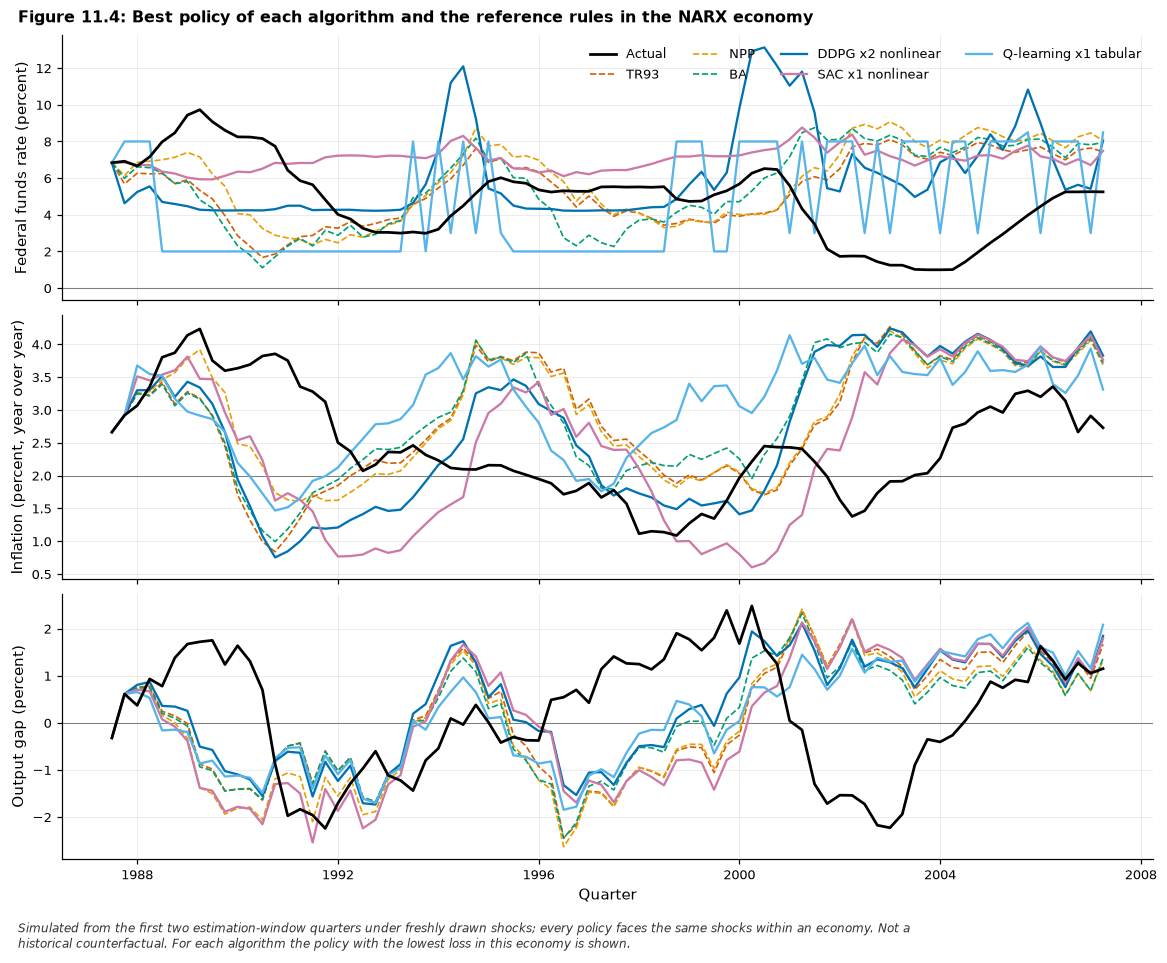

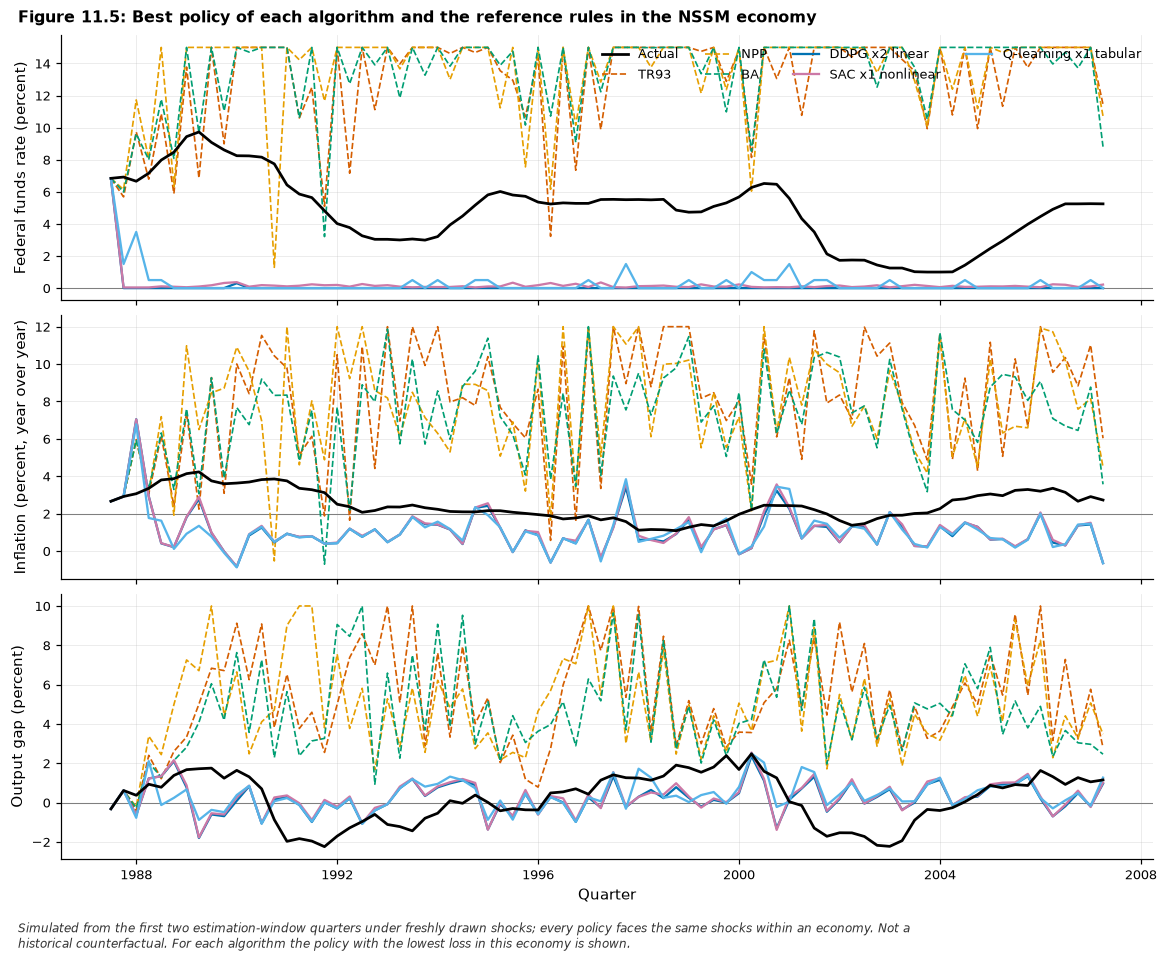

In [5]:
paths_by_economy = {
    env_name: lab.simulate_policies(env_name, cells) for env_name in lab.env_names
}
loss_table = lab.loss_table(paths_by_economy)

for env_name, paths in paths_by_economy.items():
    shown = {
        name: path for name, path in paths.items() if name in ("Actual", *lab.reference_rules())
    }
    for algo in ALGORITHMS:
        labels = [c.label for c in cells if c.env_name == env_name and c.algo == algo]
        best = loss_table.loc[env_name].loc[labels, "Loss"].idxmin()
        shown[best] = paths[best]
    fig = plots.policy_paths(shown, pi_star=cfg.pi_star)
    nb.figure(
        fig,
        f"best_policies_{slug(env_name)}",
        f"Best policy of each algorithm and the reference rules in the {env_name} economy",
        note=PATH_NOTE
        + " For each algorithm the policy with the lowest loss in this economy is shown.",
    )

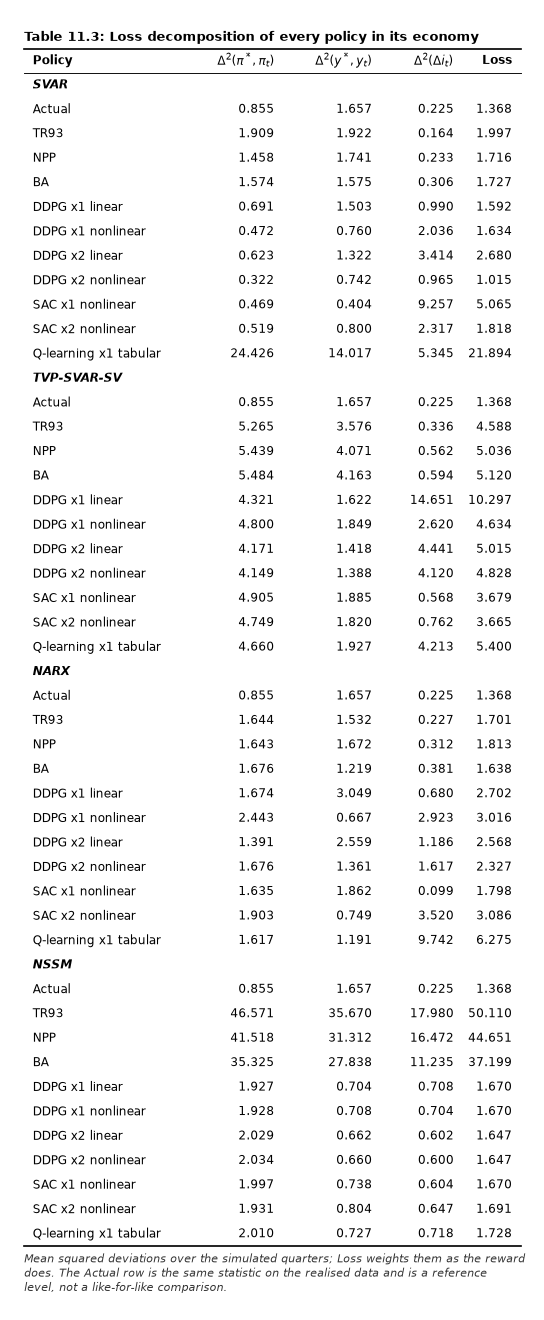

In [6]:
nb.table(
    loss_table.rename(columns=LOSS_COLUMNS),
    "loss_decomposition",
    "Loss decomposition of every policy in its economy",
    fontsize=8.0,
    note=(
        "Mean squared deviations over the simulated quarters; Loss weights them as the reward"
        " does. The Actual row is the same statistic on the realised data and is a reference"
        " level, not a like-for-like comparison."
    ),
)

### Discussion and limitations

**Faithful to H&T (with documented departures):**
- All four economy environments use the parent notebooks' fitted models directly; the two linear
  economies come from the `cultivars` edition of the linear-environment notebook.
- The agent's action $i_t$ is correctly mapped to $i_{t-1}$ in the *next* period's transition equation.
- Linear and nonlinear actor variants are plain `torch.nn` modules with H&T eq. 12-13 semantics and no
  extraneous output `tanh` squash.
- Both observation specifications $x_t^{(1)}$ and $x_t^{(2)}$ trained for every applicable cell.
- Hidden-node search over critic and (nonlinear) actor nodes; agent selection by ER/ES filter
  followed by the steady-state-reward tie-break.

**Pragmatic deviations from H&T:**
- Default architecture grid is narrower than H&T's full $\{1, \ldots, 10\}$ ranges. Setting
  `cfg.with_full_grid()` in notebook `07_rl_environments` recovers the full grid at an order-of-magnitude longer
  wall-clock.
- The TVP-SVAR-SV environment uses the smoothed posterior mean at the training endpoint
  (2007Q2). Because the parent notebook fits the TVP model on the full sample including out-of-sample
  data, this anchor incorporates a small amount of post-2007 information. Coefficients, the
  contemporaneous coefficient and the volatilities are posterior-mean plug-ins; the posterior draws
  are not propagated into the environment.
- The reward function adds a Sack-Wieland $(\Delta i)^2$ smoothing term (cf. H&T eq. 16 which
  omits it). This is needed because without it the agent learns a bang-bang policy. The smoothing
  term is standard in the optimal-monetary-policy literature. The lagged rate it depends on is not
  part of either observation specification, so the agent cannot condition on it.
- The agent-selection filter is loosened from ER/ES > -4 (H&T) to ER/ES > -50 during the
  search phase to accumulate candidates from the NSSM environment, which extrapolates badly.
  The steady-state-reward tiebreaker still picks the winner.
- A macro-state clamp at $\pm 10$ percentage points around steady state prevents runaway
  trajectories from dominating the agent-selection bookkeeping.
- The counterfactual paths are simulations under freshly drawn shocks with a common seed, not the
  historical counterfactual of H&T Section 3.3, which feeds the estimated structural shocks back
  through the economy. The "Actual FFR" loss row is therefore a reference level, not a like-for-like
  comparison.

**DSGE exercise limitations:**
- We implement only the Rudebusch & Svensson (1999) backward-looking benchmark. The 10
  forward-looking models in H&T's exercise require solving rational-expectations equilibria
  via Sims's (2002) `gensys` or an equivalent, which we do not embed here. A full replication
  is a follow-on contribution.
- The nonlinear policies (DDPG nonlinear, SAC, Q-learning) are evaluated in the DSGE exercise
  using an OLS-linearised approximation of their reaction functions. The DSGE comparison requires
  linear feedback, and H&T exclude their nonlinear ANN policies from it for that reason, so these rows
  discard the precise nonlinearities of the learned policies.

# References

## 6.2 Papers and books

- Adam, K., & Billi, R. M. (2006). Optimal monetary policy under commitment with a zero bound on nominal interest rates. *Journal of Money, Credit and Banking*, 38(7), 1877-1905.
- Bellman, R. (1957). *Dynamic Programming*. Princeton University Press.
- Bou, A., Bettini, M., Dittert, S., Kumar, V., Sodhani, S., Yang, X., De Fabritiis, G., & Moens, V. (2023). TorchRL: A data-driven decision-making library for PyTorch. *arXiv preprint arXiv:2306.00577*.
- Cogley, T., & Sargent, T. J. (2005). Drifts and volatilities: Monetary policies and outcomes in the post WWII US. *Review of Economic Dynamics*, 8(2), 262-302.
- Fraccaro, M., Sonderby, S. K., Paquet, U., & Winther, O. (2016). Sequential neural models with stochastic layers. In *Advances in Neural Information Processing Systems 29* (pp. 2199-2207).
- Giacomini, R., & White, H. (2006). Tests of conditional predictive ability. *Econometrica*, 74(6), 1545-1578.
- Glorot, X., & Bengio, Y. (2010). Understanding the difficulty of training deep feedforward neural networks. In *Proceedings of the 13th International Conference on Artificial Intelligence and Statistics* (pp. 249-256).
- Goodfriend, M. (2004). Inflation targeting in the United States? In B. S. Bernanke & M. Woodford (Eds.), *The Inflation-Targeting Debate* (pp. 311-352). University of Chicago Press.
- Haarnoja, T., Zhou, A., Abbeel, P., & Levine, S. (2018). Soft actor-critic: Off-policy maximum entropy deep reinforcement learning with a stochastic actor. In *Proceedings of the 35th International Conference on Machine Learning* (Vol. 80, pp. 1861-1870).
- Hawkins, R. J., Speakes, J. K., & Hamilton, D. E. (2015). Monetary policy and PID control. *Journal of Economic Interaction and Coordination*, 10(1), 183-197.
- Hinterlang, N., & Tänzer, A. (2021). Optimal monetary policy using reinforcement learning. *Deutsche Bundesbank Discussion Paper No. 51/2021*.
- Howard, R. A. (1960). *Dynamic Programming and Markov Processes*. MIT Press.
- Krishnan, R. G., Shalit, U., & Sontag, D. (2017). Structured inference networks for nonlinear state space models. In *Proceedings of the 31st AAAI Conference on Artificial Intelligence* (pp. 2101-2109).
- Levenberg, K. (1944). A method for the solution of certain non-linear problems in least squares. *Quarterly of Applied Mathematics*, 2(2), 164-168.
- Lillicrap, T. P., Hunt, J. J., Pritzel, A., Heess, N., Erez, T., Tassa, Y., Silver, D., & Wierstra, D. (2015). Continuous control with deep reinforcement learning. *arXiv preprint arXiv:1509.02971*.
- Lucas, R. E., Jr. (1976). Econometric policy evaluation: A critique. *Carnegie-Rochester Conference Series on Public Policy*, 1, 19-46.
- Marquardt, D. W. (1963). An algorithm for least-squares estimation of nonlinear parameters. *Journal of the Society for Industrial and Applied Mathematics*, 11(2), 431-441.
- Mnih, V., Kavukcuoglu, K., Silver, D., Graves, A., Antonoglou, I., Wierstra, D., & Riedmiller, M. (2013). Playing Atari with deep reinforcement learning. *arXiv preprint arXiv:1312.5602*.
- Mnih, V., Kavukcuoglu, K., Silver, D., Rusu, A. A., Veness, J., Bellemare, M. G., Graves, A., Riedmiller, M., Fidjeland, A. K., Ostrovski, G., Petersen, S., Beattie, C., Sadik, A., Antonoglou, I., King, H., Kumaran, D., Wierstra, D., Legg, S., & Hassabis, D. (2015). Human-level control through deep reinforcement learning. *Nature*, 518(7540), 529-533.
- Nair, V., & Hinton, G. E. (2010). Rectified linear units improve restricted Boltzmann machines. In *Proceedings of the 27th International Conference on Machine Learning* (pp. 807-814).
- Nguyen, D., & Widrow, B. (1990). Improving the learning speed of 2-layer neural networks by choosing initial values of the adaptive weights. In *International Joint Conference on Neural Networks* (Vol. 3, pp. 21-26).
- Nikolsko-Rzhevskyy, A., Papell, D. H., & Prodan, R. (2018). The Taylor principles. *Journal of Macroeconomics*, 55, 14-30.
- Orphanides, A., & Wieland, V. (2000). Inflation zone targeting. *European Economic Review*, 44(7), 1351-1387.
- Primiceri, G. E. (2005). Time varying structural vector autoregressions and monetary policy. *Review of Economic Studies*, 72(3), 821-852.
- Rangapuram, S. S., Seeger, M., Gasthaus, J., Stella, L., Wang, Y., & Januschowski, T. (2018). Deep state space models for time series forecasting. In *Advances in Neural Information Processing Systems 31* (pp. 7796-7805).
- Rotemberg, J. J., & Woodford, M. (1997). An optimization-based econometric framework for the evaluation of monetary policy. *NBER Macroeconomics Annual*, 12, 297-346.
- Rudebusch, G. D., & Svensson, L. E. O. (1999). Policy rules for inflation targeting. In J. B. Taylor (Ed.), *Monetary Policy Rules* (pp. 203-262). University of Chicago Press.
- Sack, B., & Wieland, V. (2000). Interest-rate smoothing and optimal monetary policy: A review of recent empirical evidence. *Journal of Economics and Business*, 52(1-2), 205-228.
- Saxe, A. M., McClelland, J. L., & Ganguli, S. (2014). Exact solutions to the nonlinear dynamics of learning in deep linear neural networks. In *International Conference on Learning Representations*.
- Silver, D., Lever, G., Heess, N., Degris, T., Wierstra, D., & Riedmiller, M. (2014). Deterministic policy gradient algorithms. In *Proceedings of the 31st International Conference on Machine Learning* (pp. 387-395).
- Sims, C. A. (2002). Solving linear rational expectations models. *Computational Economics*, 20(1-2), 1-20.
- Sutton, R. S., & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press.
- Svensson, L. E. O. (2020). Monetary policy strategies for the Federal Reserve. *International Journal of Central Banking*, 16(1), 133-193.
- Taylor, J. B. (1993). Discretion versus policy rules in practice. *Carnegie-Rochester Conference Series on Public Policy*, 39, 195-214.
- Wang, J., Feinstein, A., & Chen, M. (2026). Reinforcement learning in monetary policy: A comparison of algorithmic approaches. *Stanford University Working Paper*.
- Watkins, C. J. C. H. (1989). *Learning from delayed rewards* (Doctoral dissertation). King's College, University of Cambridge.
- Watkins, C. J. C. H., & Dayan, P. (1992). Q-learning. *Machine Learning*, 8(3-4), 279-292.
- Wieland, V., Cwik, T., Müller, G. J., Schmidt, S., & Wolters, M. (2012). A new comparative approach to macroeconomic modeling and policy analysis. *Journal of Economic Behavior & Organization*, 83(3), 523-541.
- Wieland, V., Afanasyeva, E., Kuete, M., & Yoo, J. (2016). New methods for macro-financial model comparison and policy analysis. In J. B. Taylor & H. Uhlig (Eds.), *Handbook of Macroeconomics* (Vol. 2, pp. 1241-1319). Elsevier.
- Woodford, M. (2003). *Interest and Prices: Foundations of a Theory of Monetary Policy*. Princeton University Press.

# Export

The last cell converts this notebook to PDF in the shared `documents/` directory. A kernel can only
convert the copy saved on disk, so the cell waits briefly for the editor to save; if the file is still
behind, it writes nothing and asks you to save and run it again.

In [7]:
nb.export_pdf()

/var/folders/cj/p5jdwnb923752l7zjc_69j5w0000gn/T/ipykernel_83930/281924391.py:1: UserWarning: 11_rl_robustness_comparison.ipynb on disk does not yet contain this run's outputs, so no PDF was written. Save the notebook and run this cell again.
  nb.export_pdf()
